In [2]:
%run setup_matplotlib.ipynb

In [20]:
from scaueclib import OnlineBivariate
import numpy as np
from tqdm import tqdm

dim = 2500

g0_bivariate = OnlineBivariate(dim)
g1_bivariate = OnlineBivariate(dim)

N = 500000
for i in tqdm(range(N)): # Test all cases
    sample = np.load(f"./trace_masked_pairwise_mul_v2/sample_{i:08}.npz")
    trace = sample["trace"]

    coin = np.random.randint(0, 2)
    if coin == 0:
        g0_bivariate.update(trace)
    else:
        g1_bivariate.update(trace)

tvalues_rnd_rnd_500K = g0_bivariate.welch_t_against(g1_bivariate)
np.save("tvalues_rnd_rnd_500K.npy", tvalues_rnd_rnd_500K)
print("t-values for RND vs RND are saved")

100%|█████████████████████████████████████████████████████████████| 500000/500000 [22:06<00:00, 377.02it/s]

t-values for RND vs RND are saved


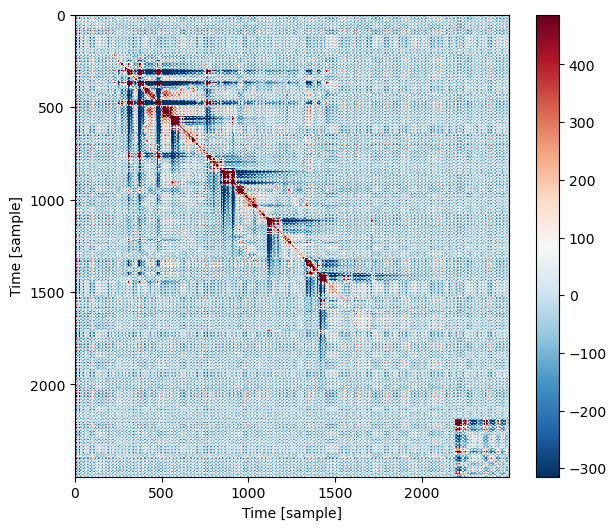

In [21]:
import matplotlib.pyplot as plt

heatmap_masked_mul = g0_bivariate.get_cov()

# data: 2D array
vmin, vmax = np.percentile(heatmap_masked_mul, [1, 99.5])

plt.figure(figsize=(7, 6))
im = plt.imshow(
    heatmap_masked_mul,
    cmap="RdBu_r",      # 視認性の高い連続カラーマップ
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest",
    aspect="auto"
)
plt.colorbar(im)
plt.ylabel("Time [sample]")
plt.xlabel("Time [sample]")

target_posx = 1325
target_posy = 1025
plot_range = 100
#plt.xlim(target_posx - plot_range, target_posx + plot_range)
#plt.ylim(target_posy + plot_range, target_posy - plot_range)

plt.show()

## argmax of t_00 ~ t_11: 506 795 1058 1355

In [ ]:
import matplotlib.pyplot as plt

#heatmap_masked_mul = g0_bivariate.welch_t_against(g1_bivariate)
tvalues_rnd_rnd_500K = np.load("tvalues_rnd_rnd_500K.npy")
tvalues_rnd_rnd_500K = np.abs(tvalues_rnd_rnd_500K)

plt.figure(figsize=(7, 6))
im = plt.imshow(
    tvalues_rnd_rnd_500K)
 
plt.colorbar(im)
plt.ylabel("Time [sample]")
plt.xlabel("Time [sample]")

target_posx = 1325
target_posy = 950
plot_range = 100
#plt.xlim(target_posx - plot_range, target_posx + plot_range)
#plt.ylim(target_posy + plot_range, target_posy - plot_range)

plt.show()

## argmax of t_00 ~ t_11: 506 795 1058 1355

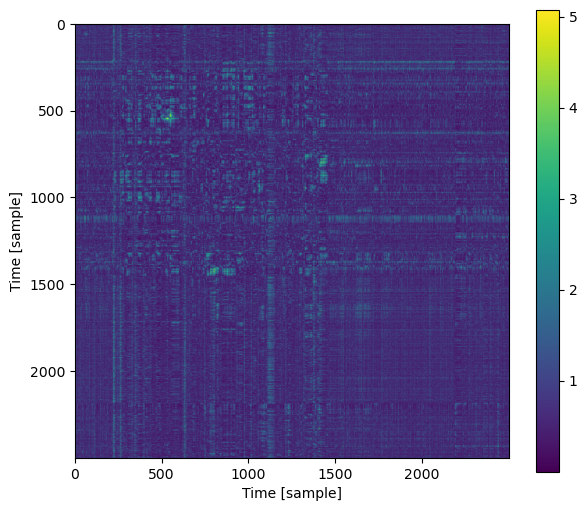

In [69]:
from scaueclib import OnlineBivariate
import numpy as np
from tqdm import tqdm

dim = 2500

g0_bivariate = OnlineBivariate(dim)
g1_bivariate = OnlineBivariate(dim)

N = 5000
for i in tqdm(range(N)): # Test all cases
    sample = np.load(f"./trace_masked_pairwise_mul_ttest/sample_{i:08}.npz")
    trace = sample["trace"]
    coin = sample["coin"]
    
    if coin == 0:
        g0_bivariate.update(trace)
    else:
        g1_bivariate.update(trace)

tvalues_rnd_fix_500K = g0_bivariate.welch_t_against(g1_bivariate)
np.save("tvalues_rnd_fix_500K.npy", tvalues_rnd_fix_500K)
print("t-values for RND vs FIXED are saved")

100%|█████████████████████████████████████████████████████████████████| 5000/5000 [00:12<00:00, 395.67it/s]

t-values for RND vs FIXED are saved


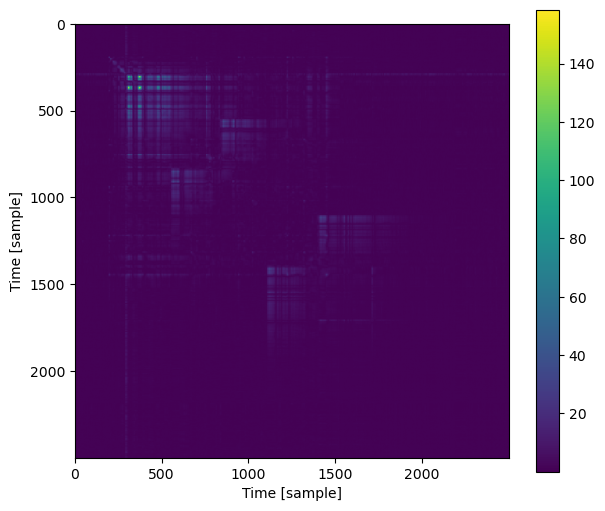

In [70]:
import matplotlib.pyplot as plt

tvalues_rnd_fix_500K = np.load("tvalues_rnd_fix_500K.npy")
tvalues_rnd_fix_500K = np.abs(tvalues_rnd_fix_500K)

plt.figure(figsize=(7, 6))
im = plt.imshow(
    tvalues_rnd_fix_500K)
 
plt.colorbar(im)
plt.ylabel("Time [sample]")
plt.xlabel("Time [sample]")

target_posx = 1325
target_posy = 950
plot_range = 100
#plt.xlim(target_posx - plot_range, target_posx + plot_range)
#plt.ylim(target_posy + plot_range, target_posy - plot_range)

plt.show()

## argmax of t_00 ~ t_11: 506 795 1058 1355

In [71]:
tvalues = np.zeros((dim, dim))

## Below diagonal
for i in range(0, dim):
    for j in range(0, i+1):
        tvalues[i][j] = tvalues_rnd_fix_500K[i][j]
        
## Above diagonal
for i in range(0, dim):
    for j in range(i, dim):
        tvalues[i][j] = tvalues_rnd_rnd_500K[i][j]


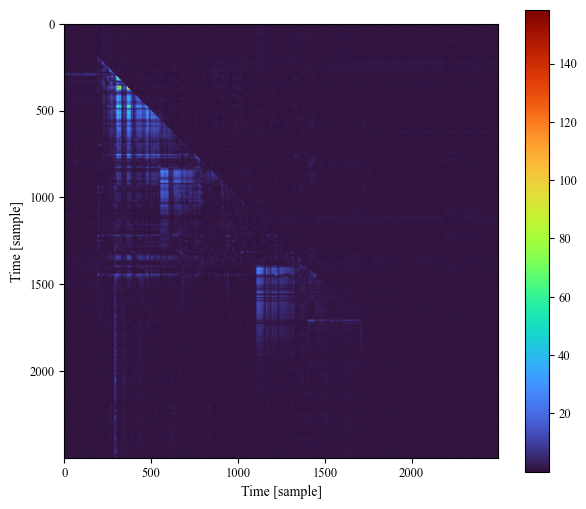

158.45284924896956

In [102]:
plt.figure(figsize=(7, 6))
im = plt.imshow(
    tvalues,
    cmap="turbo", origin="upper")

plt.colorbar()

plt.ylabel("Time [sample]")
plt.xlabel("Time [sample]")

plt.savefig("images/bivariate_ttest.pdf", bbox_inches='tight')

plt.show()
np.max(tvalues)
# Below diagonal: 
# Above diagonal: 

In [103]:
!pdfcrop images/bivariate_ttest.pdf

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `images/bivariate_ttest-crop.pdf'.


100%|████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3427.28it/s]


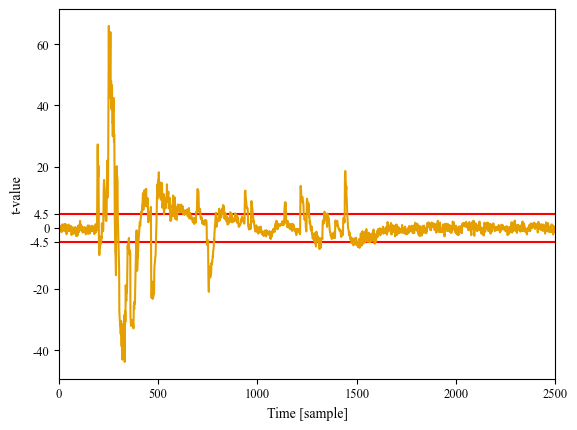

In [108]:
## First-order ttest

from scaueclib import OnlineTVLA
import numpy as np
from tqdm import tqdm

dim = 2500

online_vec = OnlineTVLA(dim)
N = 1000
for i in tqdm(range(N)): # Test all cases
    sample = np.load(f"./trace_masked_pairwise_mul_ttest/sample_{i:08}.npz")
    trace = sample["trace"]
    coin = sample["coin"]
    
    online_vec.update(trace, coin)

tvalues_first_rnd_fix_1K = online_vec.get_tvalue()
#np.save("tvalues_first_rnd_fix_500K.npy", tvalues_first_rnd_fix_500K)
#print("t-values for RND vs FIXED are saved")

plt.xlim(0, dim)
plt.xlabel("Time [sample]")
plt.ylabel("t-value")

plt.hlines(4.5, 0, dim, color="red")
plt.hlines(-4.5, 0, dim, color="red")

plt.yticks([-4.5, 4.5, 0, -20, 20, -40, 40, 60], ["-4.5", "4.5", "0", "-20", "20", "-40", "40", "60"])
plt.plot(tvalues_first_rnd_fix_1K)

plt.savefig("images/ttest_first_1K.pdf", bbox_inches='tight')
plt.show()

In [109]:
!pdfcrop images/ttest_first_1K.pdf

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `images/ttest_first_1K-crop.pdf'.


In [5]:
## First-order ttest

from scaueclib import OnlineTVLA
import numpy as np
from tqdm import tqdm

dim = 2500

online_vec = OnlineTVLA(dim)
N = 500000
for i in tqdm(range(N)): # Test all cases
    sample = np.load(f"./trace_masked_pairwise_mul_v2/sample_{i:08}.npz")
    trace = sample["trace"]

    coin = np.random.randint(0, 2)
    online_vec.update(trace, coin)

tvalues_first_rnd_rnd_500K = online_vec.get_tvalue()
np.save("tvalues_first_rnd_rnd_500K.npy", tvalues_first_rnd_rnd_500K)
print("t-values for RND vs RND are saved")



100%|████████████████████████████████████████████████████████████| 500000/500000 [01:37<00:00, 5130.36it/s]

t-values for RND vs RND are saved


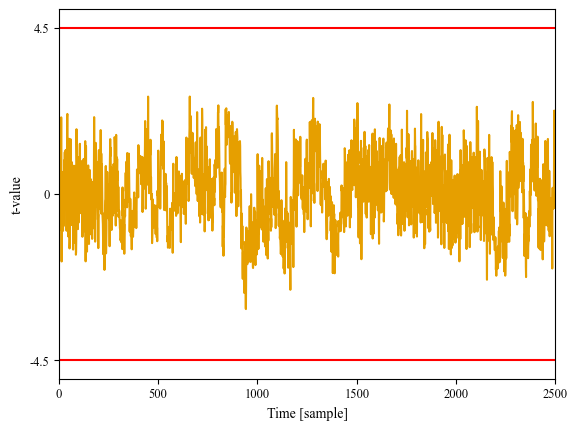

In [7]:
tvalues_first_rnd_rnd_500K = np.load("tvalues_first_rnd_rnd_500K.npy")

plt.plot(tvalues_first_rnd_rnd_500K)
plt.xlim(0, dim)
plt.ylim(-5, 5)
plt.xlabel("Time [sample]")
plt.ylabel("t-value")

plt.hlines(4.5, 0, dim, color="red")
plt.hlines(-4.5, 0, dim, color="red")

plt.yticks([-4.5, 4.5, 0], ["-4.5", "4.5", "0"])

plt.savefig("images/ttest_first_RND_RND_500K.pdf", bbox_inches="tight")

plt.show()

In [8]:
!pdfcrop images/ttest_first_RND_RND_500K.pdf

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `images/ttest_first_RND_RND_500K-crop.pdf'.
